# Random forest - Housing Prices

Objetivo: entrenar un random forest para regresión y evaluar en entrenamiento y prueba.

## 1) Librerias

In [ ]:
!pip install pandas matplotlib seaborn scikit-learn


In [1]:
# Datos
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor


## 2) Cargar datos

In [2]:
# Esto se debe cambiar por la ruta correcta del dataset
# Leer archivo
data = pd.read_csv("abalone.csv")


In [29]:
# Vista rapida
data.head()


,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [30]:
# Tipos de columnas
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Sex             4177 non-null   category
 1   Length          4177 non-null   float64 
 2   Diameter        4177 non-null   float64 
 3   Height          4177 non-null   float64 
 4   Whole_weight    4177 non-null   float64 
 5   Shucked_weight  4177 non-null   float64 
 6   Viscera_weight  4177 non-null   float64 
 7   Shell_weight    4177 non-null   float64 
 8   Rings           4177 non-null   int64   
dtypes: category(1), float64(7), int64(1)
memory usage: 265.4 KB


In [31]:
data.columns

Index(['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight',
       'Viscera_weight', 'Shell_weight', 'Rings'],
      dtype='str')

## 3) Preparar datos

In [32]:
# NOTA: Deben cambiar esto por los que correspondan a su dataset.

variables_a_descartar = []

variables_categoricas = ["Sex"]
variables_numericas = [
    'Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight',
       'Viscera_weight', 'Shell_weight'
]
variables_ordinales = []

# Descartamos variables que no deberian aportar informacion, o que
# al contrario, pueden aportar información pero tienen muchos valores únicos,
# lo que dificulta su uso directo en modelos de machine learning.
variable_dependiente = "Rings"

In [33]:
for var in variables_categoricas:
    data[var] = data[var].astype("category")

In [34]:
# Deben elegir uno de estos caminos

# Eliminar faltantes clave (si es que hay)
# datos_modelo = data.dropna(subset=["RM", "LSTAT"])

# Imputar faltantes (si es que hay)
# data["RM"] = data["RM"].fillna(data["RM"].median())

In [35]:
# Resumen
data.describe(include="all")


,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
count,4177,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
unique,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,NaN,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,NaN,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,NaN,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,NaN,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,NaN,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000


In [36]:
X = data.drop([variable_dependiente] + variables_a_descartar, axis=1)
y = data[variable_dependiente]


In [37]:
y.head()


0    15
1     7
2     9
3    10
4     7
Name: Rings, dtype: int64

In [38]:
# En regresión, la variable dependiente debe ser numérica.
# Si su variable objetivo viniera como texto, conviértanla antes de entrenar.
# Por ejemplo:
# y = pd.to_numeric(y, errors="coerce")

## 4) Separar entrenamiento y prueba (80/20)

In [39]:
random_state = 42 # Esta semilla asegura que los resultados sean reproducibles

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state
)

## 5) Variables para random forest (numéricas)

In [62]:
# Este modelo combina muchos árboles para reducir varianza y mejorar estabilidad.
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html
# Hiperparametros a ajustar: n_estimators, max_depth, max_features.
modelo = RandomForestRegressor(n_estimators=200, random_state=random_state, max_depth=4)

# 1) Este es un ejemplo de pipeline que incluye imputación de valores faltantes,
# escalado de variables numéricas y codificación de variables categóricas.
#
# 2) Los pipelines permiten encadenar varios pasos de preprocesamiento y modelado,
# lo que facilita la gestión del flujo de trabajo y reduce el riesgo de errores.
#
# 3) Se pueden combinar con ColumnTransformers para aplicar diferentes transformaciones a
# diferentes tipos de variables (numéricas, categóricas, ordinales, etc.).
pipeline = Pipeline([
    ("preprocesamiento", ColumnTransformer([
        ("numerico", Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler()),
        ]), variables_numericas),
        ("categorico", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(drop="first", sparse_output=False)),
        ]), variables_categoricas)
    ])),
    ("modelo", modelo)
])

## 6) Entrenar y predecir

In [63]:
# Ajustar modelo
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerico', ...), ('categorico', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

,feature,importance,absolute_importance
6,numerico__Shell_weight,0.817058,0.817058
4,numerico__Shucked_weight,0.124707,0.124707
7,categorico__Sex_I,0.021881,0.021881
1,numerico__Diameter,0.017530,0.017530
3,numerico__Whole_weight,0.006759,0.006759
2,numerico__Height,0.006070,0.006070
5,numerico__Viscera_weight,0.003404,0.003404
0,numerico__Length,0.002227,0.002227
8,categorico__Sex_M,0.000364,0.000364


Text(0.5, 1.0, 'Importancia de las características según los coeficientes del modelo')

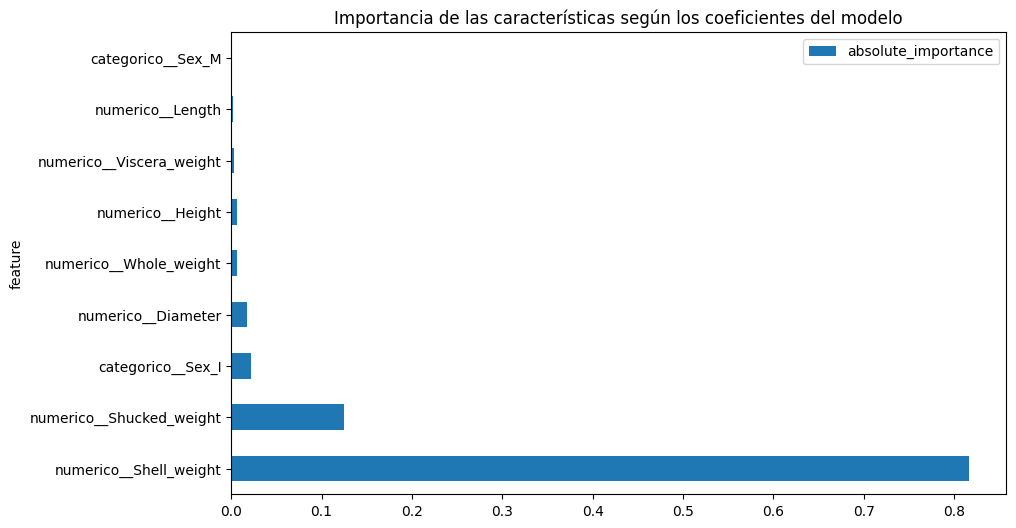

In [64]:
feature_importances = pipeline.named_steps["modelo"].feature_importances_
feature_names = pipeline.named_steps["preprocesamiento"].get_feature_names_out()

feature_importances_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances,
    "absolute_importance": np.abs(feature_importances)
}).sort_values(by="absolute_importance", ascending=False)
display(feature_importances_df)
feature_importances_df.plot(x="feature", y="absolute_importance", kind="barh", figsize=(10, 6))
plt.title("Importancia de las características según los coeficientes del modelo")

In [65]:
# Prediccion entrenamiento
y_train_pred = pipeline.predict(X_train)

In [66]:
# Prediccion prueba
y_test_pred = pipeline.predict(X_test)

In [67]:
# Comparacion rapida en prueba
pd.DataFrame({
    "Real": y_test.values,
    "Predicho": y_test_pred,
    "Residuo": y_test.values - y_test_pred
}).head()

,Real,Predicho,Residuo
0,9,11.317480,-2.317480
1,8,9.993569,-1.993569
2,16,13.042888,2.957112
3,9,11.766575,-2.766575
4,14,10.978879,3.021121


In [68]:
y.describe()

count    4177.000000
mean        9.933684
std         3.224169
min         1.000000
25%         8.000000
50%         9.000000
75%        11.000000
max        29.000000
Name: Rings, dtype: float64

## 7) Evaluacion

In [69]:
# Métricas entrenamiento
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = root_mean_squared_error(y_train, y_train_pred)
train_mape = mean_absolute_percentage_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"MAE entrenamiento: {train_mae:.4f}")
print(f"MSE entrenamiento: {train_mse:.4f}")
print(f"RMSE entrenamiento: {train_rmse:.4f}")
print(f"MAPE entrenamiento: {train_mape:.4f}")
print(f"R² entrenamiento: {train_r2:.4f}")

MAE entrenamiento: 1.5298
MSE entrenamiento: 4.6430
RMSE entrenamiento: 2.1548
MAPE entrenamiento: 0.1516
R² entrenamiento: 0.5485


In [70]:
# Métricas prueba
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = root_mean_squared_error(y_test, y_test_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"MAE prueba: {test_mae:.4f}")
print(f"MSE prueba: {test_mse:.4f}")
print(f"RMSE prueba: {test_rmse:.4f}")
print(f"R² prueba: {test_r2:.4f}")
print(f"MAPE prueba: {test_mape:.4f}")

MAE prueba: 1.6213
MSE prueba: 5.3059
RMSE prueba: 2.3035
R² prueba: 0.5099
MAPE prueba: 0.1583


In [71]:
# Resumen de métricas
pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Prueba"],
    "MAE": [train_mae, test_mae],
    "MSE": [train_mse, test_mse],
    "RMSE": [train_rmse, test_rmse],
    "R2": [train_r2, test_r2],
    "MAPE": [train_mape, test_mape]
})

,Conjunto,MAE,MSE,RMSE,R2,MAPE
0,Entrenamiento,1.529769,4.643039,2.154771,0.548517,0.151563
1,Prueba,1.621336,5.305927,2.303460,0.509855,0.158253


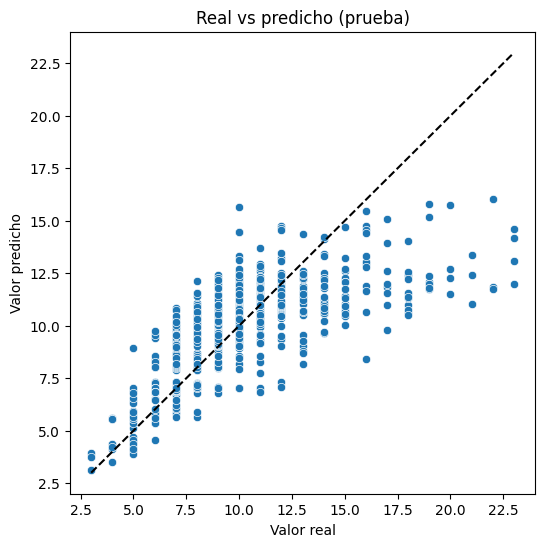

In [72]:
# Valores reales vs predichos en prueba
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_test_pred)
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Real vs predicho (prueba)")
limites = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
plt.plot(limites, limites, linestyle="--", color="black")
plt.show()

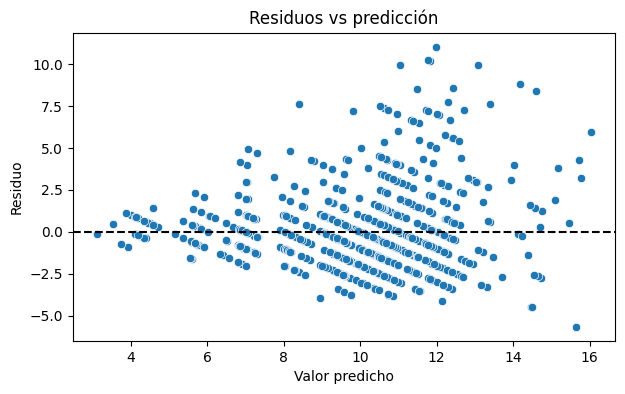

In [73]:
# Residuos en prueba
residuos = y_test - y_test_pred

plt.figure(figsize=(7, 4))
sns.scatterplot(x=y_test_pred, y=residuos)
plt.axhline(0, linestyle="--", color="black")
plt.xlabel("Valor predicho")
plt.ylabel("Residuo")
plt.title("Residuos vs predicción")
plt.show()